In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/abhishek14398/salary-dataset-simple-linear-regression/Salary_dataset.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/abhishek14398/salary-dataset-simple-linear-regression/Salary_dataset.csv')

In [3]:
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [4]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Height')

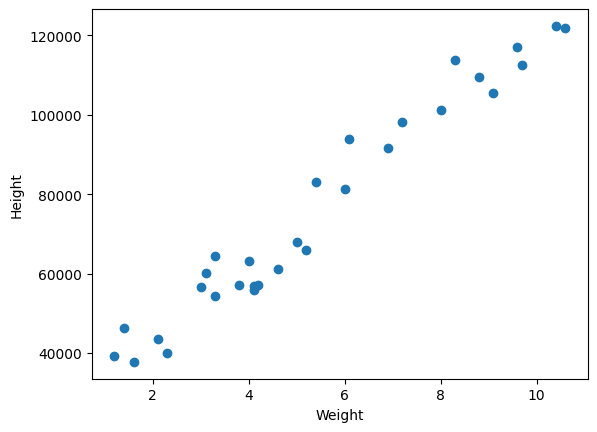

In [5]:
plt.scatter(df['YearsExperience'], df['Salary'])
plt.xlabel("Weight")
plt.ylabel("Height")

In [6]:
# Co-relation
df.corr()

,Unnamed: 0,YearsExperience,Salary
Unnamed: 0,1.000000,0.986460,0.960826
YearsExperience,0.986460,1.000000,0.978242
Salary,0.960826,0.978242,1.000000


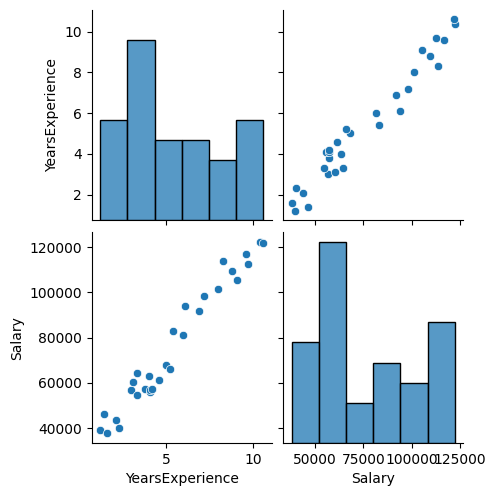

In [7]:
import seaborn as sns
sns.pairplot(df[['YearsExperience','Salary']])

Creating Independent and Dependent Series, Independent variable should always be in a 2D array or a dataframe format, dependent variables can be a series.

In [8]:
X = df[['YearsExperience']]#Difference between df[['Years']] ==> returns dataframe object and df['Years'] ==> series object
y = df['Salary'] # returns series object
np.array(X).shape

(30, 1)

In [9]:
X

,YearsExperience
0,1.2
1,1.4
2,1.6
3,2.1
4,2.3
5,3.0
6,3.1
7,3.3
8,3.3
9,3.8


In [10]:
y

0      39344.0
1      46206.0
2      37732.0
3      43526.0
4      39892.0
5      56643.0
6      60151.0
7      54446.0
8      64446.0
9      57190.0
10     63219.0
11     55795.0
12     56958.0
13     57082.0
14     61112.0
15     67939.0
16     66030.0
17     83089.0
18     81364.0
19     93941.0
20     91739.0
21     98274.0
22    101303.0
23    113813.0
24    109432.0
25    105583.0
26    116970.0
27    112636.0
28    122392.0
29    121873.0
Name: Salary, dtype: float64

In [11]:
#Time to split the data
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25, random_state=42)

#We need to standarzing when using Gradient Descent Algorithm.
Standarizing the train dataset, using Z-score which means that it converts the data using z-score = (x-mean)/std, after standarizing all the data values we get mean = 0 and std =1

In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

We use fit_transform() on X_train dataset in order to apply z-score after calculation mean and std for the training dataset, however we use only transform() on X_test dataset in order to prevent Data leakage(that is providing any sort of information about our test dataset to the model). We do that by using the previously calculated mean and std (that was meant for our training dataset).

In [15]:
# Apply Simple Linear Regression
from sklearn.linear_model import LinearRegression

In [16]:
# Creating a Linear Regression model
regression = LinearRegression()

In [17]:
regression.fit(X_train, y_train)

LinearRegression()

In [18]:
print(regression.coef_)

[25063.1519945]


In [19]:
print(regression.intercept_)

70417.40909090909


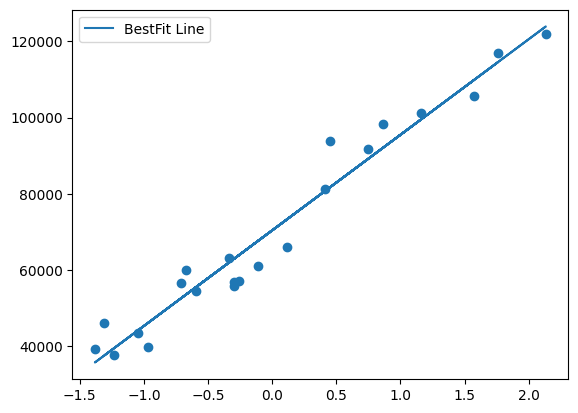

In [20]:
# Ploting the best fit line with respect to training data
plt.scatter(X_train,y_train)
plt.plot(X_train, regression.predict(X_train), label = "BestFit Line")
plt.legend()
plt.show()

In [21]:
y_pred = regression.predict(X_test)

In [22]:
#Performance Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [23]:
mse = mean_squared_error(y_test,y_pred)
print("Mean Squared Error:",mse)

Mean Squared Error: 38802588.99247059


In [24]:
mae = mean_absolute_error(y_test,y_pred)
print("Mean Absolute Error:",mae)

Mean Absolute Error: 5056.9954666635895


In [25]:
rmse = np.sqrt(mse)
print("Root Mean Squared Error:",rmse)

Root Mean Squared Error: 6229.172416338352


In [26]:
from sklearn.metrics import r2_score

In [27]:
r2 = r2_score(y_test,y_pred)
print(r2)

0.9347210011126783


In [28]:
#n = int(input("Enter the number of years of experience you have: "))
print("You should expect a salary near to:", regression.predict(scaler.transform([[4]])))

You should expect a salary near to: [62026.09014682]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
